# Implement and Test a PyTorch-Based Classifier

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Build, train, and evaluate a CNN in PyTorch for binary
classification of agricultural vs. non-agricultural satellite land tiles.


## 1. Import libraries and packages

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_DIR = "images_dataSAT"
assert os.path.isdir(DATA_DIR), f"'{DATA_DIR}' not found."


Using device: cpu


### Task 1: Explain the usefulness of random initialization

Neural network weights are initialized to small **random** values (rather
than all zeros, or a single constant) so that different neurons in the
same layer start out computing different functions. If every weight were
initialized identically, every neuron in a layer would receive the same
gradient during backpropagation and update identically forever -- the
network would never be able to differentiate itself into a rich set of
learned features (this is sometimes called the "symmetry problem").
Random initialization breaks this symmetry, letting each neuron learn a
distinct feature; it also helps keep the scale of activations and
gradients reasonable early in training, which improves convergence
speed and stability. Setting a fixed random **seed** (as we do above)
doesn't remove this benefit -- it just makes the specific random values
reproducible across runs.


### Task 2: Define `train_transform` pipeline

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

print(train_transform)


Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


### Task 3: Define the `val_transform` pipeline

Validation data should **not** be randomly augmented -- we want a
consistent, deterministic view of each validation image so that
evaluation metrics are stable and comparable across epochs.


In [3]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

print(val_transform)


Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## 2. Build train/validation datasets and loaders

In [4]:
full_dataset_train_view = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
full_dataset_val_view = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

n_total = len(full_dataset_train_view)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, _ = random_split(full_dataset_train_view, [n_train, n_val], generator=generator)
generator = torch.Generator().manual_seed(SEED)
_, val_subset_indices = random_split(full_dataset_val_view, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
print(f"Train samples: {len(train_subset)}")


Train samples: 4800


### Task 4: Create `val_loader` for the validation dataset

In [5]:
val_loader = DataLoader(val_subset_indices, batch_size=32, shuffle=False)

print(f"Validation samples: {len(val_subset_indices)}")
print(f"Validation batches: {len(val_loader)}")


Validation samples: 1200
Validation batches: 38


### Task 5: Purpose of `tqdm`

`tqdm` wraps an iterable (like our `DataLoader`) and displays a live
progress bar in the notebook -- showing how many batches have been
processed, the current iteration rate, and an estimated time remaining.
It's purely a usability/monitoring tool: it has no effect on training
correctness, but makes it much easier to see that training is
progressing (and roughly how long an epoch will take) instead of staring
at a blank cell.


## 3. CNN architecture

In [6]:
class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


pytorch_model = SatelliteCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=1e-3)
print(pytorch_model)


SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_fea

## 4. Training loop

### Task 6: Why are `train_loss`, `train_correct`, and `train_total` reset every epoch?

These are running accumulators used to compute **that epoch's** average
loss and accuracy. If they weren't reset at the start of each epoch,
they would keep accumulating across all previous epochs too, making the
reported metrics a running average over the *entire* training history
instead of a true per-epoch measurement -- which would hide whether the
model is actually improving or getting worse on the current epoch's data.

### Task 7: Why use `torch.no_grad()` in the validation loop?

`torch.no_grad()` disables PyTorch's automatic gradient tracking for
everything inside the block. During validation we only need a forward
pass to compute predictions/metrics -- we never call `.backward()` or
update weights. Skipping gradient tracking saves memory (no need to
store intermediate activations for backprop) and speeds up the forward
pass, with no effect on correctness since gradients aren't needed anyway.


In [7]:
EPOCHS = 4
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

t0 = time.perf_counter()
for epoch in range(EPOCHS):
    pytorch_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0  # reset every epoch (see Task 6)

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]", mininterval=5.0):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = pytorch_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_loss += loss.item() * labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # --- Validation ---
    pytorch_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():  # see Task 7
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]", mininterval=5.0):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            logits = pytorch_model(images)
            loss = criterion(logits, labels)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss += loss.item() * labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {epoch_train_loss:.4f} - "
          f"train_acc: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - "
          f"val_acc: {epoch_val_acc:.4f}")

t1 = time.perf_counter()
print(f"\nTotal training time: {t1 - t0:.1f} s")


Epoch 1/4 [train]:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/4 [train]:  12%|█▏        | 18/150 [00:05<00:37,  3.50it/s]

Epoch 1/4 [train]:  25%|██▌       | 38/150 [00:10<00:29,  3.75it/s]

Epoch 1/4 [train]:  39%|███▊      | 58/150 [00:15<00:24,  3.82it/s]

Epoch 1/4 [train]:  52%|█████▏    | 78/150 [00:20<00:18,  3.88it/s]

...

Epoch 4/4 [train]:  96%|█████████▌| 144/150 [00:41<00:01,  3.45it/s]

Epoch 4/4 [train]: 100%|██████████| 150/150 [00:43<00:00,  3.47it/s]

Epoch 4/4 [val]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 4/4 [val]: 100%|██████████| 38/38 [00:03<00:00, 10.51it/s]

Epoch 4/4 - train_loss: 0.0325 - train_acc: 0.9908 - val_loss: 0.0142 - val_acc: 0.9950

Total training time: 180.0 s


### Task 8: List two metrics used to evaluate training performance

In the training loop above, we tracked **loss** (binary cross-entropy,
via `BCEWithLogitsLoss`) and **accuracy** (fraction of correctly
classified samples, via comparing thresholded predictions to labels),
for both the training and validation sets each epoch.


### Task 9: Plot model training loss

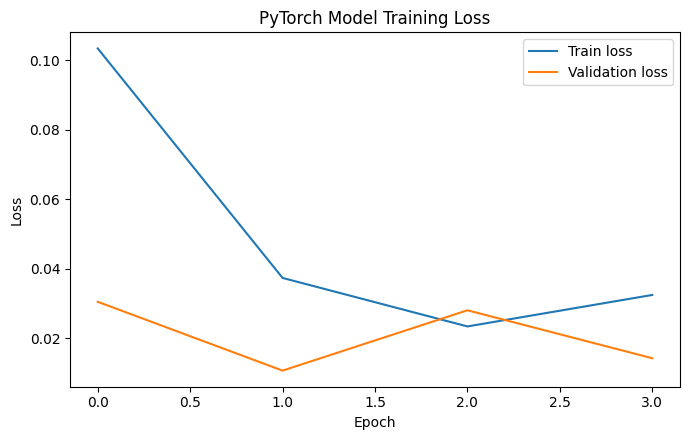

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("PyTorch Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


### Task 10: Retrieve predictions `all_preds` and ground truth `all_labels` from `val_loader`

In [9]:
pytorch_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = pytorch_model(images)
        preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy().ravel()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().ravel())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"all_preds shape: {all_preds.shape}")
print(f"all_labels shape: {all_labels.shape}")

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


all_preds shape: (1200,)
all_labels shape: (1200,)

Accuracy : 0.9950
Precision: 0.9897
Recall   : 1.0000
F1-score : 0.9948


## 5. Save the trained model (needed for later labs)

In [10]:
torch.save(pytorch_model.state_dict(), "pytorch_cnn_classifier.pt")
print("Saved model weights to pytorch_cnn_classifier.pt")


Saved model weights to pytorch_cnn_classifier.pt


## Summary

We implemented and tested a PyTorch CNN classifier, covering: the role
of random weight initialization, separate `train_transform` /
`val_transform` pipelines, `val_loader` construction, the purpose of
`tqdm` progress bars, why per-epoch accumulators are reset, why
`torch.no_grad()` is used during validation, loss/accuracy as the two
core training metrics, a training-loss plot, and retrieval of
`all_preds` / `all_labels` for final evaluation.
